# Visualization – Charts for the Employee Performance Study

Every chart is saved as an image in `src/visualization/figures` for use in the summary and presentation.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

ROOT = Path("../..").resolve()
RAW_FILE = ROOT / "data" / "raw" / "INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1_8.xls"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "src" / "models"
FIGURES = ROOT / "src" / "visualization" / "figures"
TARGET = "PerformanceRating"
RANDOM_STATE = 42

import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
FIGURES.mkdir(parents=True, exist_ok=True)
data = pd.read_csv(PROCESSED / "employee_cleaned.csv")
ranking = pd.read_csv(PROCESSED / "feature_ranking.csv")
with open(MODELS / "model_metadata.json") as f:
    metadata = json.load(f)
PALETTE = {2: "#d95f5f", 3: "#4c78a8", 4: "#54a24b"}
LABELS = {2: "2 – Good", 3: "3 – Excellent", 4: "4 – Outstanding"}

def finish(name):
    plt.tight_layout()
    plt.savefig(FIGURES / name, dpi=160, bbox_inches="tight")
    plt.show()

## 1. Distribution of performance ratings

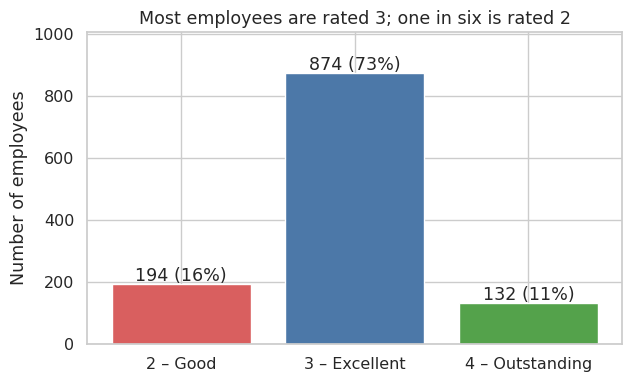

In [2]:
counts = data[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar([LABELS[i] for i in counts.index], counts.values, color=[PALETTE[i] for i in counts.index])
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 10, f"{value} ({value / len(data):.0%})", ha="center")
ax.set_title("Most employees are rated 3; one in six is rated 2")
ax.set_ylabel("Number of employees")
ax.set_ylim(0, counts.max() * 1.15)
finish("01_rating_distribution.png")

## 2. Department wise performance

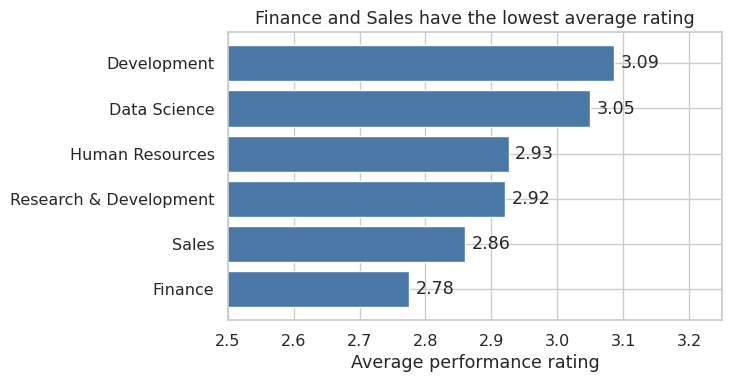

In [3]:
average = data.groupby("EmpDepartment")[TARGET].mean().sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(average.index, average.values, color="#4c78a8")
for y, value in enumerate(average.values):
    ax.text(value + 0.01, y, f"{value:.2f}", va="center")
ax.set_xlim(2.5, 3.25)
ax.set_xlabel("Average performance rating")
ax.set_title("Finance and Sales have the lowest average rating")
finish("02_department_average_rating.png")

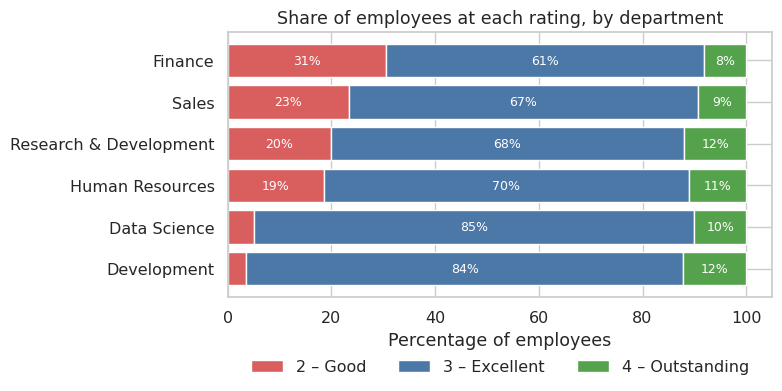

In [4]:
mix = (pd.crosstab(data["EmpDepartment"], data[TARGET], normalize="index") * 100)
mix = mix.loc[mix[2].sort_values().index]
fig, ax = plt.subplots(figsize=(8, 4.2))
left = np.zeros(len(mix))
for rating in [2, 3, 4]:
    ax.barh(mix.index, mix[rating], left=left, color=PALETTE[rating], label=LABELS[rating])
    for y, (start, width) in enumerate(zip(left, mix[rating])):
        if width > 6:
            ax.text(start + width / 2, y, f"{width:.0f}%", ha="center", va="center", color="white", fontsize=9)
    left += mix[rating].values
ax.set_xlabel("Percentage of employees")
ax.set_title("Share of employees at each rating, by department")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
finish("03_department_rating_mix.png")

## 3. The three most important factors

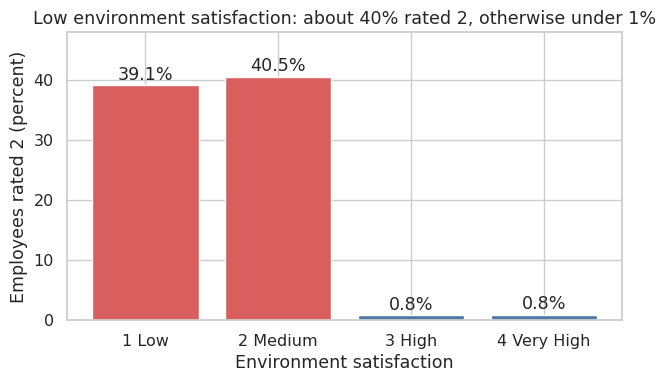

In [5]:
share2 = data.groupby("EmpEnvironmentSatisfaction")[TARGET].apply(lambda s: (s == 2).mean() * 100)
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(["1 Low", "2 Medium", "3 High", "4 Very High"], share2.values, color=["#d95f5f", "#d95f5f", "#4c78a8", "#4c78a8"])
for bar, value in zip(bars, share2.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center")
ax.set_ylabel("Employees rated 2 (percent)")
ax.set_xlabel("Environment satisfaction")
ax.set_title("Low environment satisfaction: about 40% rated 2, otherwise under 1%")
ax.set_ylim(0, 48)
finish("04_factor_environment_satisfaction.png")

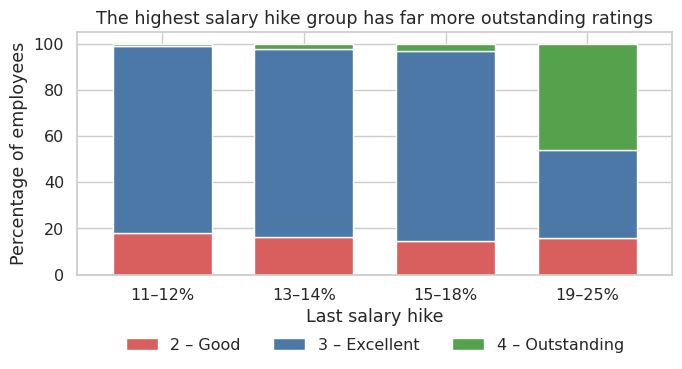

In [6]:
bands = pd.cut(data["EmpLastSalaryHikePercent"], [10, 12, 14, 18, 25], labels=["11–12%", "13–14%", "15–18%", "19–25%"])
mix = pd.crosstab(bands, data[TARGET], normalize="index") * 100
fig, ax = plt.subplots(figsize=(7, 4))
mix.plot(kind="bar", stacked=True, color=[PALETTE[c] for c in mix.columns], ax=ax, width=0.7)
ax.set_xlabel("Last salary hike")
ax.set_ylabel("Percentage of employees")
ax.set_title("The highest salary hike group has far more outstanding ratings")
ax.legend([LABELS[c] for c in mix.columns], loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
plt.xticks(rotation=0)
finish("05_factor_salary_hike.png")

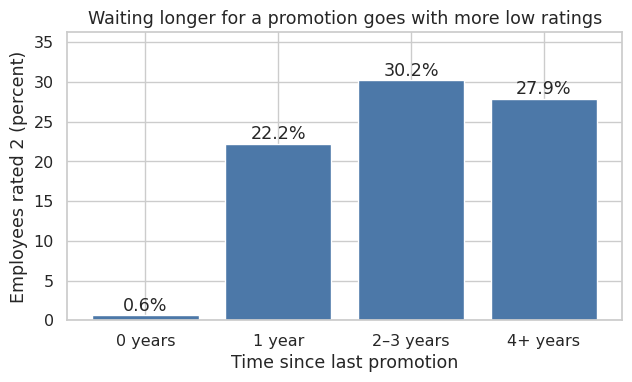

In [7]:
gap = pd.cut(data["YearsSinceLastPromotion"], [-1, 0, 1, 3, 15], labels=["0 years", "1 year", "2–3 years", "4+ years"])
share2 = data.groupby(gap)[TARGET].apply(lambda s: (s == 2).mean() * 100)
fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(share2.index.astype(str), share2.values, color="#4c78a8")
for bar, value in zip(bars, share2.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.6, f"{value:.1f}%", ha="center")
ax.set_ylabel("Employees rated 2 (percent)")
ax.set_xlabel("Time since last promotion")
ax.set_title("Waiting longer for a promotion goes with more low ratings")
ax.set_ylim(0, share2.max() * 1.2)
finish("06_factor_promotion_gap.png")

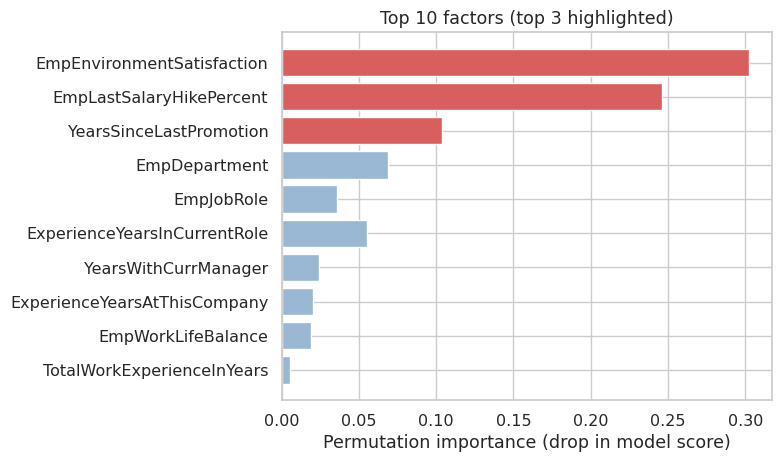

In [8]:
top = ranking.sort_values("average_rank").head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.8))
colors = ["#d95f5f" if i >= 7 else "#9ab7d3" for i in range(len(top))]
ax.barh(top["feature"], top["permutation_importance"], color=colors)
ax.set_xlabel("Permutation importance (drop in model score)")
ax.set_title("Top 10 factors (top 3 highlighted)")
finish("07_factor_ranking.png")

## 4. Model results

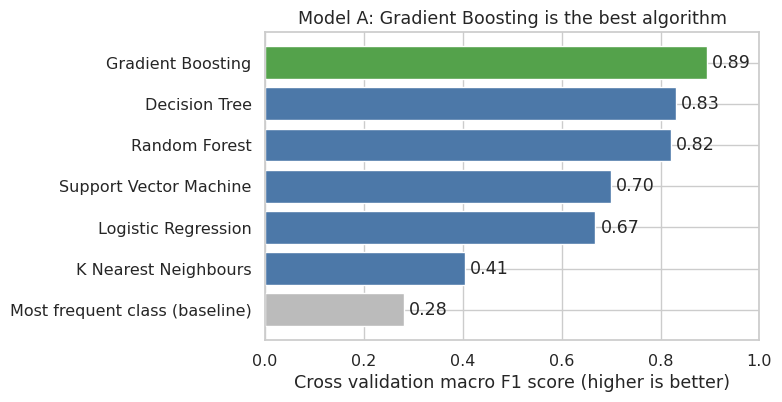

In [9]:
all_models = pd.read_csv(PROCESSED / "model_comparison_all_factors.csv").sort_values("cv_macro_f1")
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#bbbbbb" if "baseline" in m else ("#54a24b" if m == all_models.iloc[-1]["model"] else "#4c78a8") for m in all_models["model"]]
ax.barh(all_models["model"], all_models["cv_macro_f1"], color=colors)
for y, value in enumerate(all_models["cv_macro_f1"]):
    ax.text(value + 0.01, y, f"{value:.2f}", va="center")
ax.set_xlim(0, 1)
ax.set_xlabel("Cross validation macro F1 score (higher is better)")
ax.set_title("Model A: Gradient Boosting is the best algorithm")
finish("08_model_comparison.png")

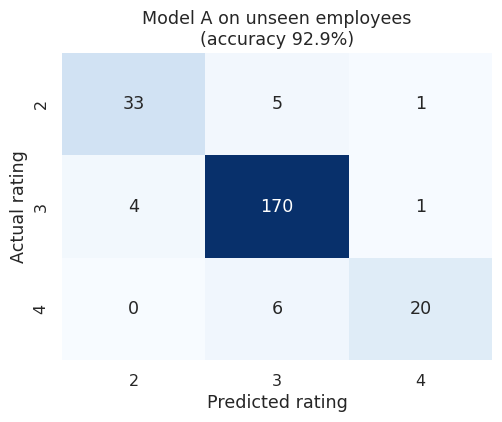

In [10]:
matrix = np.array(metadata["model_a"]["test"]["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=[2, 3, 4], yticklabels=[2, 3, 4])
ax.set_xlabel("Predicted rating")
ax.set_ylabel("Actual rating")
ax.set_title(f"Model A on unseen employees\n(accuracy {metadata['model_a']['test']['accuracy']:.1%})")
finish("09_confusion_matrix_model_a.png")

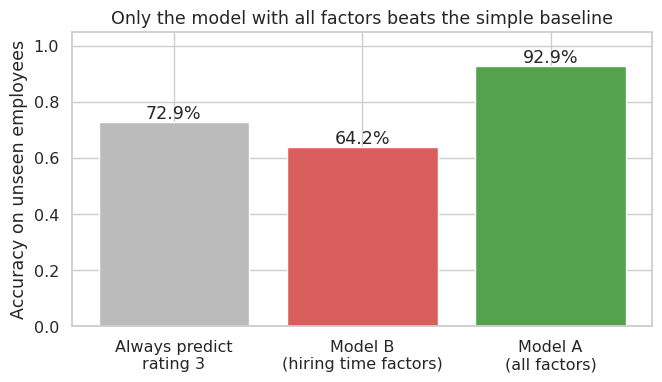

In [11]:
values = {"Always predict\nrating 3": metadata["baseline_accuracy"],
          "Model B\n(hiring time factors)": metadata["model_b"]["test"]["accuracy"],
          "Model A\n(all factors)": metadata["model_a"]["test"]["accuracy"]}
fig, ax = plt.subplots(figsize=(6.8, 4))
bars = ax.bar(values.keys(), values.values(), color=["#bbbbbb", "#d95f5f", "#54a24b"])
for bar, value in zip(bars, values.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.1%}", ha="center")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy on unseen employees")
ax.set_title("Only the model with all factors beats the simple baseline")
finish("10_accuracy_comparison.png")